In [ ]:
import numpy as np
import pandas as pd

train_df = pd.read_csv("data/Assignment_3/fashion_mnist/fashion-mnist_train.csv")
test_df = pd.read_csv("data/Assignment_3/fashion_mnist/fashion-mnist_test.csv")

# immediately isko ndarray me convert kiya
train_data = np.array(train_df, dtype="float32")
test_data = np.array(test_df, dtype="float32")

# aur X_train, X_test, y_train, y_test bana diye.
X_train, X_test, y_train, y_test = (
    train_data[:, 1:],
    test_data[:, 1:],
    train_data[:, 0],
    test_data[:, 0],
)

print(
    f"Train-{X_train.shape}, {y_train.shape}\nTest-{X_test.shape}, {y_test.shape}\n",
)


Train-(60000, 784), (60000,)
Test-(10000, 784), (10000,)



In [4]:
classes = [
    "t-shirt",
    "trouser",
    "pullover",
    "dress",
    "jacket",
    "sandal",
    "shirt",
    "shoes",
    "bag",
    "ankle boot",
]


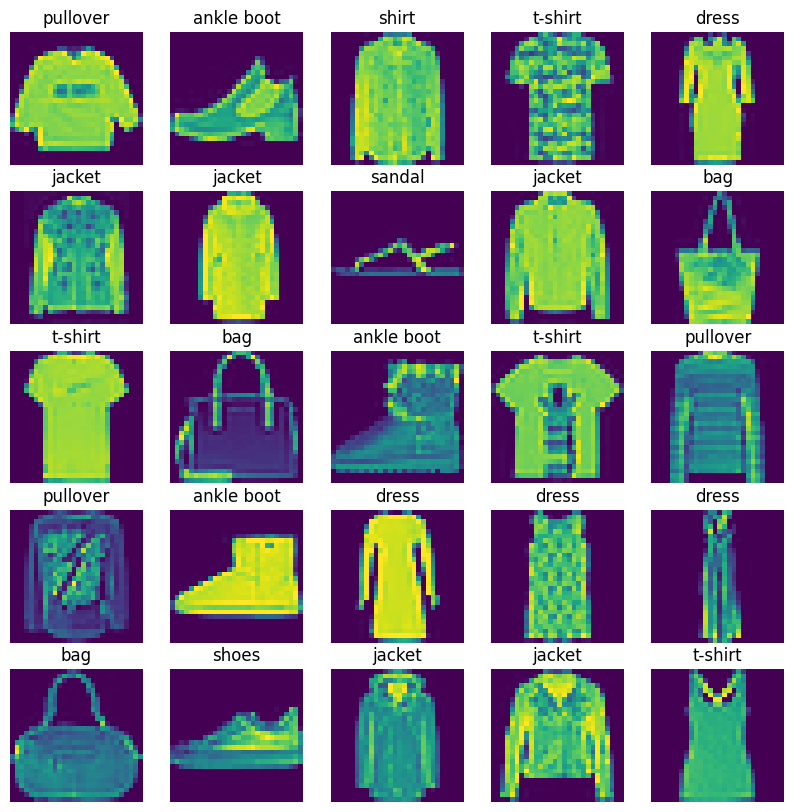

In [6]:
# visualize, visualize, visualize
import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=5, nrows=5, figsize=(10, 10))
axs = axs.ravel()
for i in range(25):
    axs[i].imshow(X_train[i].reshape(28, 28))
    axs[i].set_title(classes[int(y_train[i])])
    axs[i].axis("off")


In [7]:
# ek baar visualize ho gaya, toh fir pixels wale vector ko shape dena hai (28, 28, 1)

image_shape = (28, 28, 1)

X_train = X_train.reshape(X_train.shape[0], *image_shape)
X_test = X_test.reshape(X_test.shape[0], *image_shape)

print(
    f"Train - {X_train.shape}, {y_train.shape} \n"
    f"Test - {X_test.shape}, {y_test.shape} \n",
)


Train - (60000, 28, 28, 1), (60000,) 
Test - (10000, 28, 28, 1), (10000,) 



In [ ]:
# and then, create and fit the model

from keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    Input,
    MaxPooling2D,
)
from keras.models import Sequential
from keras.optimizers import Adam

model = Sequential(
    [
        Input(image_shape),
        Conv2D(filters=32, kernel_size=3, activation="relu"),
        BatchNormalization(),
        Conv2D(filters=32, kernel_size=3, activation="relu"),
        MaxPooling2D(pool_size=2),
        Dropout(0.25),
        Conv2D(filters=64, kernel_size=3, activation="relu"),
        BatchNormalization(),
        Conv2D(filters=64, kernel_size=3, activation="relu"),
        MaxPooling2D(pool_size=2),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax"),
    ],
)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"],
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    batch_size=2048,
    epochs=75,
    validation_data=(X_test, y_test),
    verbose=1,
)


Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.5055 - loss: 1.7356 - val_accuracy: 0.7130 - val_loss: 0.9041
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7412 - loss: 0.7190 - val_accuracy: 0.7890 - val_loss: 0.5682
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8225 - loss: 0.4740 - val_accuracy: 0.8577 - val_loss: 0.3858
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8709 - loss: 0.3585 - val_accuracy: 0.8855 - val_loss: 0.3277
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8855 - loss: 0.3158 - val_accuracy: 0.8899 - val_loss: 0.3162
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8925 - loss: 0.2973 - val_accuracy: 0.8916 - val_loss: 0.3170
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8983 - loss: 0.2826 - val_accuracy: 0.8935 - val_loss: 0.3075
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9015 - loss: 0.2735 - 

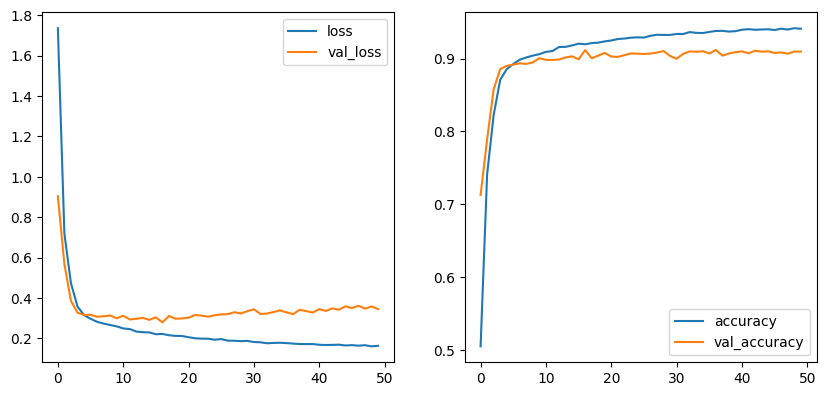

In [11]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


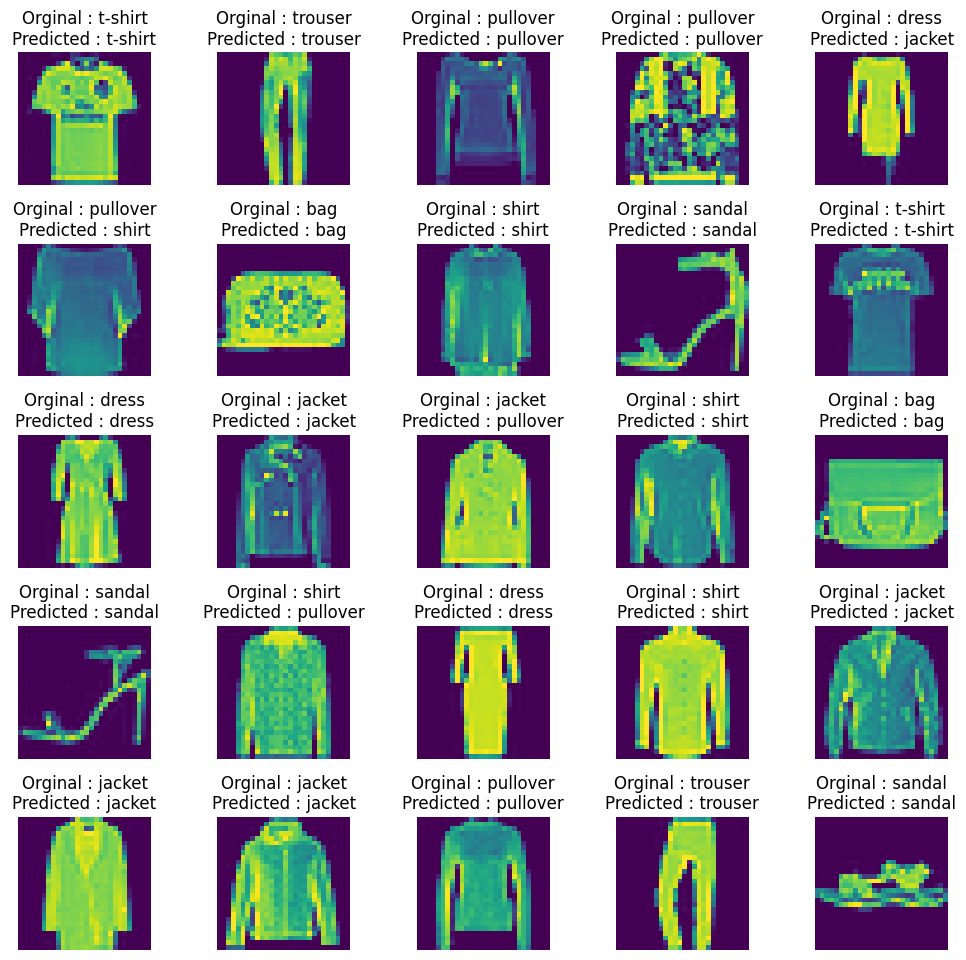

In [12]:
y_pred = np.argmax(model.predict(X_test), axis=1)

fig, axs = plt.subplots(ncols=5, nrows=5, figsize=(12, 12))
axs = axs.ravel()
for i in range(25):
    axs[i].imshow(X_test[i].reshape((28, 28)))
    axs[i].set_title(
        f"Orginal : {classes[int(y_test[i])]}\nPredicted : {classes[int(y_pred[i])]}"
    )
    axs[i].axis("off")

fig.subplots_adjust(wspace=0.5)
